In [45]:
# ============================================================
# STEP 1 : INSTALL REQUIRED LIBRARIES
# ============================================================

!pip -q install -U transformers datasets accelerate evaluate sentencepiece scikit-learn seaborn

In [46]:
# ============================================================
# STEP 2 : IMPORT LIBRARIES
# ============================================================

import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import transformers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

warnings.filterwarnings("ignore")

print("="*60)
print("Libraries Imported Successfully")
print("="*60)

print("PyTorch Version      :", torch.__version__)
print("Transformers Version :", transformers.__version__)
print("Pandas Version       :", pd.__version__)
print("NumPy Version        :", np.__version__)

Libraries Imported Successfully
PyTorch Version      : 2.11.0+cpu
Transformers Version : 5.13.1
Pandas Version       : 2.2.2
NumPy Version        : 2.0.2


In [47]:
# ============================================================
# STEP 3 : MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

print("Google Drive Mounted Successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive Mounted Successfully!


In [48]:
# ============================================================
# STEP 4 : SET RANDOM SEED
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random Seed Set Successfully!")

Random Seed Set Successfully!


In [49]:
# ============================================================
# STEP 5 : CHECK DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

Device : cpu
Running on CPU


In [50]:
# ============================================================
# STEP 6 : DATASET PATH
# ============================================================

dataset_path = "/content/drive/MyDrive/Public_Complaints_Classification_DL/dataset/complaints_dataset.csv"

print(dataset_path)

/content/drive/MyDrive/Public_Complaints_Classification_DL/dataset/complaints_dataset.csv


In [51]:
# ============================================================
# STEP 7 : LOAD DATASET
# ============================================================

df = pd.read_csv(dataset_path)

print("="*60)
print("Dataset Loaded Successfully")
print("="*60)

print("Shape :", df.shape)

display(df.head())

Dataset Loaded Successfully
Shape : (1600, 2)


,complaint,department
0,I wish to lodge a complaint regarding the fact...,Electricity
1,This is an emergency situation. illegal parkin...,Transport
2,the water tanker never arrives on time in the ...,Water Supply
3,I feel helpless because a live wire fell near ...,Electricity
4,Could you please look into the issue that the ...,Drainage


In [52]:
# ============================================================
# STEP 8 : DATASET INFORMATION
# ============================================================

print("="*60)
print("DATASET INFORMATION")
print("="*60)

df.info()

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

print("\nDepartments")
print(df["department"].value_counts())

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   complaint   1600 non-null   object
 1   department  1600 non-null   object
dtypes: object(2)
memory usage: 25.1+ KB

Missing Values
complaint     0
department    0
dtype: int64

Duplicate Rows : 0

Departments
department
Electricity     200
Transport       200
Water Supply    200
Drainage        200
Police          200
Sanitation      200
Health          200
Roads           200
Name: count, dtype: int64


In [53]:
# ============================================================
# STEP 9 : DISPLAY DATASET
# ============================================================

print("="*60)
print("FIRST 5 RECORDS")
print("="*60)

display(df.head())

print("="*60)
print("LAST 5 RECORDS")
print("="*60)

display(df.tail())

FIRST 5 RECORDS


,complaint,department
0,I wish to lodge a complaint regarding the fact...,Electricity
1,This is an emergency situation. illegal parkin...,Transport
2,the water tanker never arrives on time in the ...,Water Supply
3,I feel helpless because a live wire fell near ...,Electricity
4,Could you please look into the issue that the ...,Drainage


LAST 5 RECORDS


,complaint,department
1595,I feel helpless because the government hospita...,Health
1596,We are fed up as traffic congestion near our s...,Transport
1597,stray animals are scattering garbage all over ...,Sanitation
1598,"hi team, stray animals are scattering garbage ...",Sanitation
1599,auto rickshaw drivers near our street are over...,Transport


In [54]:
# ============================================================
# STEP 10 : DATASET STATISTICS
# ============================================================

print("="*60)
print("DATASET STATISTICS")
print("="*60)

display(df.describe(include='all'))

DATASET STATISTICS


,complaint,department
count,1600,1600
unique,1600,8
top,road maintenance near the school area has not ...,Electricity
freq,1,200


In [55]:
# ============================================================
# STEP 11 : COMPLAINT LENGTH ANALYSIS
# ============================================================

df["complaint_length"] = df["complaint"].astype(str).apply(len)

print("="*60)
print("COMPLAINT LENGTH STATISTICS")
print("="*60)

display(df["complaint_length"].describe())

COMPLAINT LENGTH STATISTICS


,complaint_length
count,1600.000000
mean,130.521250
std,42.369391
min,48.000000
25%,99.000000
50%,129.000000
75%,156.000000
max,248.000000


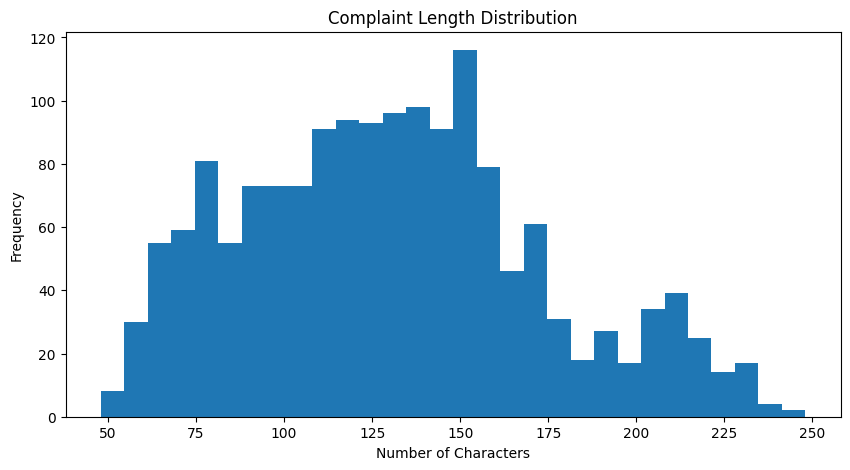

In [56]:
# ============================================================
# STEP 12 : VISUALIZE COMPLAINT LENGTH
# ============================================================

plt.figure(figsize=(10,5))

plt.hist(df["complaint_length"], bins=30)

plt.title("Complaint Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

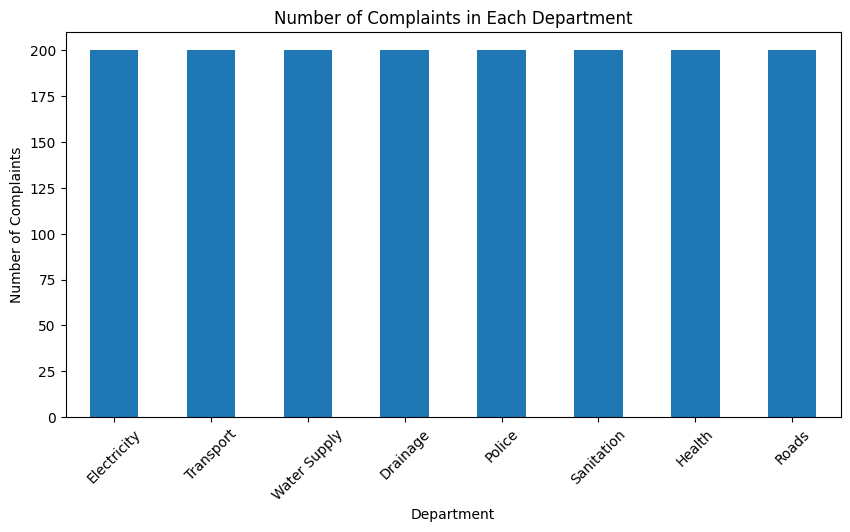

In [57]:
# ============================================================
# STEP 13 : DEPARTMENT DISTRIBUTION
# ============================================================

department_counts = df["department"].value_counts()

plt.figure(figsize=(10,5))

department_counts.plot(kind="bar")

plt.title("Number of Complaints in Each Department")
plt.xlabel("Department")
plt.ylabel("Number of Complaints")

plt.xticks(rotation=45)

plt.show()

In [58]:
# ============================================================
# STEP 14 : TEXT CLEANING
# ============================================================

df["complaint"] = df["complaint"].astype(str).str.strip()

df["department"] = df["department"].astype(str).str.strip()

print("Minimal text cleaning completed successfully.")

display(df.head())

Minimal text cleaning completed successfully.


,complaint,department,complaint_length
0,I wish to lodge a complaint regarding the fact...,Electricity,173
1,This is an emergency situation. illegal parkin...,Transport,137
2,the water tanker never arrives on time in the ...,Water Supply,163
3,I feel helpless because a live wire fell near ...,Electricity,105
4,Could you please look into the issue that the ...,Drainage,110


In [59]:
# ============================================================
# STEP 15 : LABEL ENCODING
# ============================================================

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["department"])

print("="*60)
print("LABEL MAPPING")
print("="*60)

label_mapping = dict(zip(label_encoder.classes_,
                         label_encoder.transform(label_encoder.classes_)))

print(label_mapping)

LABEL MAPPING
{'Drainage': np.int64(0), 'Electricity': np.int64(1), 'Health': np.int64(2), 'Police': np.int64(3), 'Roads': np.int64(4), 'Sanitation': np.int64(5), 'Transport': np.int64(6), 'Water Supply': np.int64(7)}


In [60]:
# ============================================================
# STEP 16 : TRAIN TEST SPLIT
# ============================================================

X = df["complaint"]

y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("="*60)
print("TRAIN TEST SPLIT COMPLETED")
print("="*60)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

TRAIN TEST SPLIT COMPLETED
Training Samples : 1280
Testing Samples  : 320


In [61]:
# ============================================================
# STEP 17 : LOAD DISTILBERT TOKENIZER
# ============================================================

from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

print("="*60)
print("TOKENIZER LOADED SUCCESSFULLY")
print("="*60)

TOKENIZER LOADED SUCCESSFULLY


In [76]:
MAX_LENGTH = 32   # reduced from 128 — complaints are short sentences

print("Maximum Length :", MAX_LENGTH)

Maximum Length : 32


In [63]:
# ============================================================
# STEP 19 : TOKENIZE TRAINING DATA
# ============================================================

train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH
)

print("="*60)
print("TRAINING DATA TOKENIZED")
print("="*60)

print("Training Samples :", len(train_encodings["input_ids"]))

TRAINING DATA TOKENIZED
Training Samples : 1280


In [64]:
# ============================================================
# STEP 20 : TOKENIZE TESTING DATA
# ============================================================

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH
)

print("="*60)
print("TESTING DATA TOKENIZED")
print("="*60)

print("Testing Samples :", len(test_encodings["input_ids"]))

TESTING DATA TOKENIZED
Testing Samples : 320


In [65]:
# ============================================================
# STEP 21 : VERIFY TOKENIZATION
# ============================================================

print("="*60)
print("TOKENIZATION SUMMARY")
print("="*60)

print("Training Encoded :", len(train_encodings["input_ids"]))
print("Testing Encoded  :", len(test_encodings["input_ids"]))

print()
print("Length of one encoded complaint :", len(train_encodings["input_ids"][0]))

TOKENIZATION SUMMARY
Training Encoded : 1280
Testing Encoded  : 320

Length of one encoded complaint : 53


In [66]:
# ============================================================
# STEP 22 : CREATE HUGGING FACE DATASET
# ============================================================

from datasets import Dataset

train_dataset = Dataset.from_dict({
    "input_ids": train_encodings["input_ids"],
    "attention_mask": train_encodings["attention_mask"],
    "labels": y_train.tolist()
})

test_dataset = Dataset.from_dict({
    "input_ids": test_encodings["input_ids"],
    "attention_mask": test_encodings["attention_mask"],
    "labels": y_test.tolist()
})

print("="*60)
print("HUGGING FACE DATASETS CREATED")
print("="*60)

print("Training Dataset :", len(train_dataset))
print("Testing Dataset  :", len(test_dataset))

HUGGING FACE DATASETS CREATED
Training Dataset : 1280
Testing Dataset  : 320


In [67]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["department"])
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

In [77]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(label_encoder.classes_)
).to(device)

for param in model.distilbert.parameters():
    param.requires_grad = False

for layer in model.distilbert.transformer.layer[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

print("MODEL LOADED — LAST 2 LAYERS UNFROZEN")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


MODEL LOADED — LAST 2 LAYERS UNFROZEN


In [69]:
# ============================================================
# STEP 24 : METRICS FUNCTION
# ============================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

print("Metrics function defined.")

Metrics function defined.


In [78]:
training_args = TrainingArguments(
    output_dir="/content/results",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=20,
    report_to="none",
    seed=SEED
)

In [79]:
# ============================================================
# STEP 26 : TRAIN THE MODEL
# ============================================================

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

train_result = trainer.train()

print("="*60)
print("TRAINING COMPLETE")
print("="*60)

Epoch,Training Loss,Validation Loss,Accuracy
1,0.603853,0.339542,0.975000
2,0.057928,0.025747,1.000000
3,0.021964,0.009335,1.000000
4,0.013925,0.006393,1.000000
5,0.009072,0.005626,1.000000


TRAINING COMPLETE


In [80]:
# ============================================================
# STEP 27 : EVALUATE ON TEST SET
# ============================================================

eval_results = trainer.evaluate()
print("="*60)
print("TEST RESULTS")
print("="*60)
print(eval_results)

Training Loss,Validation Loss,Epoch,Accuracy
0.009072,0.005626,5,1.000000


TEST RESULTS
{'eval_loss': 0.005625751800835133, 'eval_accuracy': 1.0}


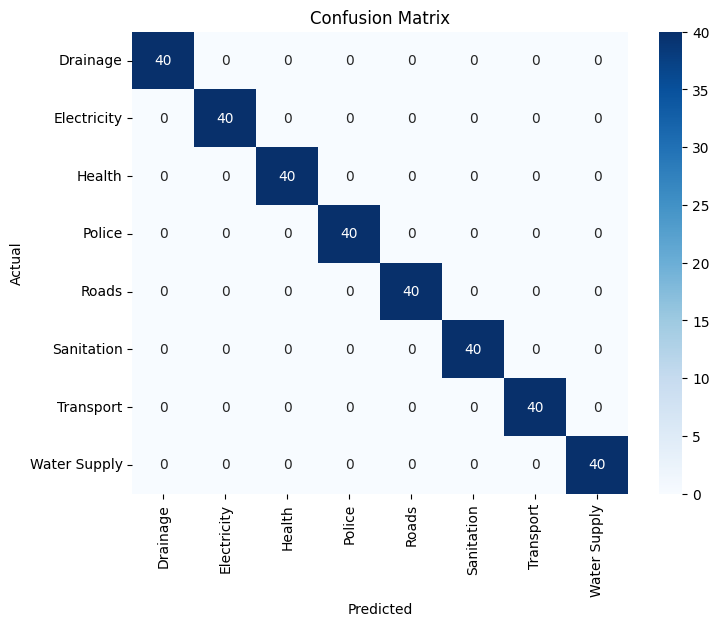

              precision    recall  f1-score   support

    Drainage       1.00      1.00      1.00        40
 Electricity       1.00      1.00      1.00        40
      Health       1.00      1.00      1.00        40
      Police       1.00      1.00      1.00        40
       Roads       1.00      1.00      1.00        40
  Sanitation       1.00      1.00      1.00        40
   Transport       1.00      1.00      1.00        40
Water Supply       1.00      1.00      1.00        40

    accuracy                           1.00       320
   macro avg       1.00      1.00      1.00       320
weighted avg       1.00      1.00      1.00       320



In [81]:
# ============================================================
# STEP 28 : CONFUSION MATRIX & CLASSIFICATION REPORT
# ============================================================

preds_output = trainer.predict(test_dataset)
y_pred = np.argmax(preds_output.predictions, axis=1)
y_true = preds_output.label_ids

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_, cmap='Blues')
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

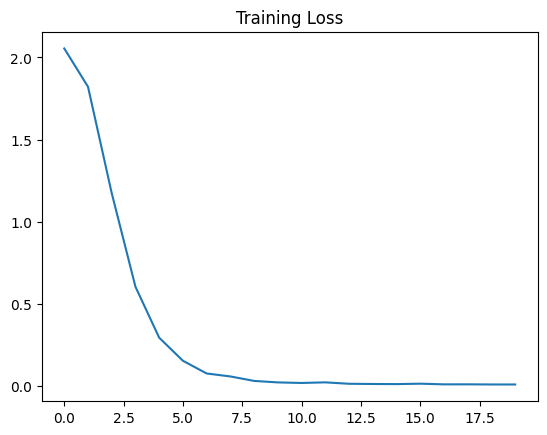

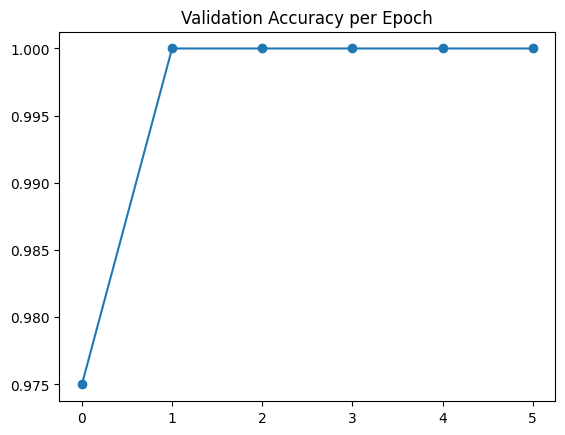

In [82]:
# ============================================================
# STEP 29 : TRAINING HISTORY PLOT
# ============================================================

logs = trainer.state.log_history
train_loss = [x["loss"] for x in logs if "loss" in x]
eval_acc = [x["eval_accuracy"] for x in logs if "eval_accuracy" in x]

plt.plot(train_loss)
plt.title("Training Loss"); plt.show()

plt.plot(eval_acc, marker='o')
plt.title("Validation Accuracy per Epoch"); plt.show()

In [83]:
# ============================================================
# STEP 30 : PREDICT ON NEW COMPLAINTS
# ============================================================

def predict_department(text):
    enc = tokenizer([text], truncation=True, padding=True,
                     max_length=MAX_LENGTH, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(**enc).logits
    pred = torch.argmax(logits, axis=1).item()
    return label_encoder.inverse_transform([pred])[0]

print(predict_department("Please fix the broken road outside my house."))
print(predict_department("My electricity meter is not working properly."))
print(predict_department("Someone broke into my neighbor's shop last night."))

Roads
Electricity
Police


In [84]:
# ============================================================
# STEP 31 : SAVE MODEL
# ============================================================

save_path = "/content/drive/MyDrive/Public_Complaints_Classification_DL/model"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print("MODEL SAVED TO:", save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

MODEL SAVED TO: /content/drive/MyDrive/Public_Complaints_Classification_DL/model


In [109]:
!git config --global user.email "amru.varshini7@gmail.com"
!git config --global user.name "P. Amrutha Varsini"

In [111]:
from google.colab import userdata

GITHUB_USERNAME = "amruvarshini7-max"
REPO_NAME = "DL_PublicComplaintsClassification_727824TUAM006"
GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")

repo_url = f"https://{GITHUB_TOKEN}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git"

!git clone {repo_url}
%cd {REPO_NAME}

Cloning into 'DL_PublicComplaintsClassification_727824TUAM006'...
remote: Repository not found.
fatal: repository 'https://github.com/amruvarshini7-max/DL_PublicComplaintsClassification_727824TUAM006.git/' not found
[Errno 2] No such file or directory: 'DL_PublicComplaintsClassification_727824TUAM006'
/content/DL_PublicComplaintsClassification_727824TUAM006


In [112]:
import os
folders = ["src", "notebooks", "docs", "models", "assets/screenshots"]
for f in folders:
    os.makedirs(f, exist_ok=True)
print("Folder structure created:", folders)

Folder structure created: ['src', 'notebooks', 'docs', 'models', 'assets/screenshots']


In [113]:
import shutil

shutil.copy(
    "/content/drive/MyDrive/Public_Complaints_Classification_DL/dataset/complaints_dataset.csv",
    "notebooks/complaints_dataset.csv"
)

shutil.copytree(
    "/content/drive/MyDrive/Public_Complaints_Classification_DL/model",
    "models/best_model",
    dirs_exist_ok=True
)

shutil.copy(
    "/content/drive/MyDrive/Public_Complaints_Classification_DL/Public_Complaints_Classification.ipynb",
    "notebooks/Public_Complaints_Classification.ipynb"
)

print("Files copied.")

Files copied.


In [114]:
gitignore_content = """__pycache__/
*.pyc
.ipynb_checkpoints/
.env
*.log
/content/results/
"""
with open(".gitignore", "w") as f:
    f.write(gitignore_content)
print(".gitignore created.")

.gitignore created.


In [115]:
requirements_content = """torch
transformers
datasets
accelerate
evaluate
sentencepiece
scikit-learn
seaborn
pandas
numpy
matplotlib
"""
with open("requirements.txt", "w") as f:
    f.write(requirements_content)
print("requirements.txt created.")

requirements.txt created.


In [116]:
readme_content = """# Public Complaints Classification (DistilBERT)

Deep learning project that classifies public complaints into the correct
government department using a fine-tuned DistilBERT model.

## Project Structure

- notebooks/ : Training notebook + dataset
- src/ : (reserved for future scripts)
- docs/ : Project documentation / report
- models/best_model/ : Saved fine-tuned model + tokenizer
- assets/screenshots/ : Result screenshots
- requirements.txt
- README.md

## Overview

- Model: distilbert-base-uncased (last 2 transformer layers fine-tuned)
- Task: Multi-class text classification
- Input: Free-text public complaint
- Output: Predicted department

## How to Run

1. Install dependencies: pip install -r requirements.txt
2. Open notebooks/Public_Complaints_Classification.ipynb in Jupyter or Colab.
3. Update dataset_path to point to your local copy of complaints_dataset.csv.
4. Run all cells to reproduce training and evaluation.

## Author

P. Amrutha Varsini
"""
with open("README.md", "w") as f:
    f.write(readme_content)
print("README.md created.")

README.md created.


In [117]:
!git lfs install
!git lfs track "models/**/*.bin"
!git lfs track "models/**/*.safetensors"
!git add .gitattributes
!git commit -m "chore: track model weights with Git LFS"
!git push origin main

Updated Git hooks.
Git LFS initialized.
"models/**/*.bin" already supported
"models/**/*.safetensors" already supported
On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   .gitignore
	modified:   notebooks/Public_Complaints_Classification.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
remote: Repository not found.
fatal: repository 'https://github.com/amruvarshini7-max/DL_PublicComplaintsClassification_727824TUAM006.git/' not found
